# MNIST手写数字识别(参考LeNet-5)

Using device: cpu
Train Epoch: 1 [19136/60000 (32%)]	Loss: 0.297893
Train Epoch: 1 [38336/60000 (64%)]	Loss: 0.104314
Train Epoch: 1 [57536/60000 (96%)]	Loss: 0.071609

Test set: Average loss: 0.0371, Accuracy: 9874/10000 (98.74%)

Train Epoch: 2 [19136/60000 (32%)]	Loss: 0.056733
Train Epoch: 2 [38336/60000 (64%)]	Loss: 0.049987
Train Epoch: 2 [57536/60000 (96%)]	Loss: 0.050342

Test set: Average loss: 0.0374, Accuracy: 9866/10000 (98.66%)

Train Epoch: 3 [19136/60000 (32%)]	Loss: 0.037972
Train Epoch: 3 [38336/60000 (64%)]	Loss: 0.034905
Train Epoch: 3 [57536/60000 (96%)]	Loss: 0.039680

Test set: Average loss: 0.0263, Accuracy: 9906/10000 (99.06%)

Train Epoch: 4 [19136/60000 (32%)]	Loss: 0.024476
Train Epoch: 4 [38336/60000 (64%)]	Loss: 0.032062
Train Epoch: 4 [57536/60000 (96%)]	Loss: 0.033887

Test set: Average loss: 0.0247, Accuracy: 9922/10000 (99.22%)

Train Epoch: 5 [19136/60000 (32%)]	Loss: 0.020237
Train Epoch: 5 [38336/60000 (64%)]	Loss: 0.027263
Train Epoch: 5 [57536/6000

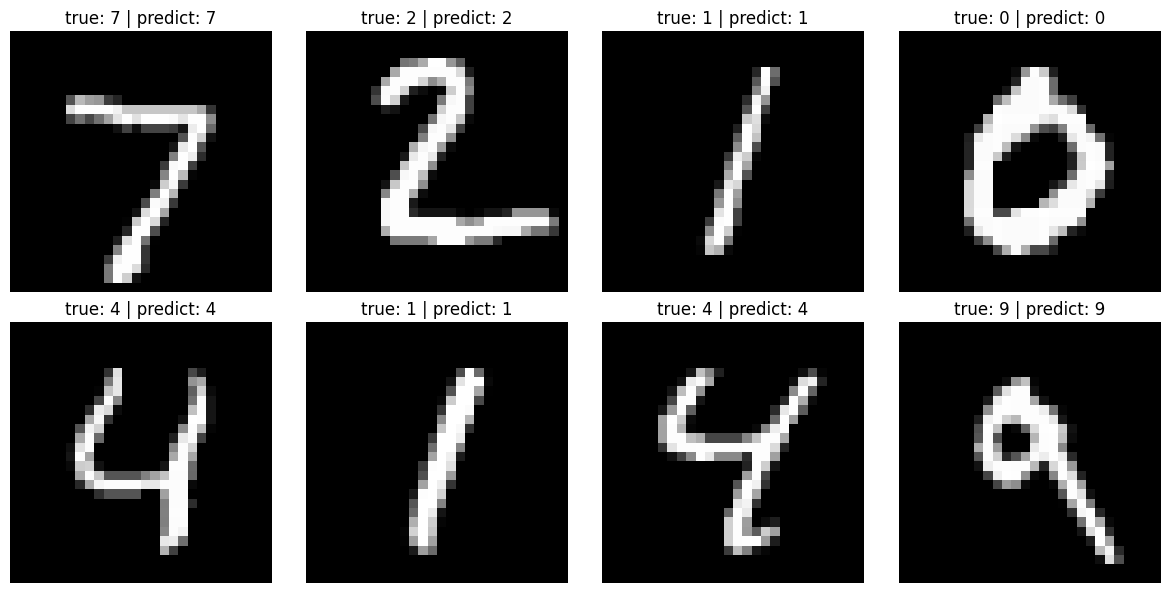

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

#自动检测GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#定义数据预处理(转为Tensor并归一化)
transform = transforms.Compose([
    transforms.ToTensor(),               # 将PIL图像转为Tensor，像素值从[0,255]归一化到[0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST数据集的均值和标准差
])

#加载数据集
train_dataset = torchvision.datasets.MNIST(
    root='../data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='../data', train=False, download=True, transform=transform
)

#创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

#定义简单的CNN模型(LeNet-5简化版)
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)  # 展平
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

#定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#训练函数
def train(epoch):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if batch_idx % 300 == 299:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {running_loss/300:.6f}')
            running_loss = 0.0

#测试函数
def test():
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    
    test_loss /= len(test_loader)
    accuracy = 100. * correct / len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} '
          f'({accuracy:.2f}%)\n')

#开始训练
epochs = 5
for epoch in range(1, epochs + 1):
    train(epoch)
    test()

#可视化预测结果
def visualize_predictions():
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

    #显示前8张图像
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    for i in range(8):
        axes[i].imshow(images[i].cpu().numpy().squeeze(), cmap='gray')
        axes[i].set_title(f'true: {labels[i].item()} | predict: {predicted[i].item()}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions()

# CIFAR-10图像分类

Using device: cpu
开始下载/加载CIFAR-10数据集...
数据集加载完成！

Epoch 1/20
[1, 200] loss: 1.827
[1, 400] loss: 1.561
[1, 600] loss: 1.435
Accuracy on test set: 54.96%

Epoch 2/20
[2, 200] loss: 1.289
[2, 400] loss: 1.234
[2, 600] loss: 1.194
Accuracy on test set: 64.97%

Epoch 3/20
[3, 200] loss: 1.116
[3, 400] loss: 1.078
[3, 600] loss: 1.064
Accuracy on test set: 68.74%

Epoch 4/20
[4, 200] loss: 1.024
[4, 400] loss: 0.981
[4, 600] loss: 0.980
Accuracy on test set: 71.00%

Epoch 5/20
[5, 200] loss: 0.929
[5, 400] loss: 0.929
[5, 600] loss: 0.925
Accuracy on test set: 74.00%

Epoch 6/20
[6, 200] loss: 0.869
[6, 400] loss: 0.867
[6, 600] loss: 0.871
Accuracy on test set: 74.71%

Epoch 7/20
[7, 200] loss: 0.832
[7, 400] loss: 0.826
[7, 600] loss: 0.820
Accuracy on test set: 75.24%

Epoch 8/20
[8, 200] loss: 0.786
[8, 400] loss: 0.789
[8, 600] loss: 0.790
Accuracy on test set: 75.70%

Epoch 9/20
[9, 200] loss: 0.768
[9, 400] loss: 0.751
[9, 600] loss: 0.760
Accuracy on test set: 77.46%

Epoch 10/20
[1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


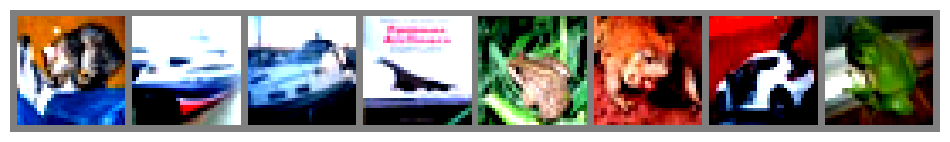

真实标签:   cat  ship  ship plane  frog  frog   car  frog
预测标签:   cat  ship  ship plane  frog  frog   car  frog


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

#设置在Jupyter中显示图像
%matplotlib inline

#设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#使用Azure镜像下载
os.environ['CIFAR10_MIRROR'] = 'https://mirror.azure.cn/pytorch-data/cifar/'

#数据预处理与增强
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),      # 数据增强：随机裁剪
    transforms.RandomHorizontalFlip(),          # 随机水平翻转
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010))  # CIFAR-10的均值和标准差
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), 
                         (0.2023, 0.1994, 0.2010))
])

#加载数据集
print("开始下载/加载CIFAR-10数据集...")
trainset = torchvision.datasets.CIFAR10(
    root='../data/CIFAR-10', train=True, download=False, transform=transform_train)
testset = torchvision.datasets.CIFAR10(
    root='../data/CIFAR-10', train=False, download=False, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')
print("数据集加载完成！")

#定义卷积神经网络
class CNNNet(nn.Module):
    def __init__(self):
        super(CNNNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        # 经过3次池化后，图像尺寸从32->16->8->4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.fc3(x)
        return x

net = CNNNet().to(device)

#损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

#训练函数
def train(epoch):
    net.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 200 == 199:
            print(f'[{epoch + 1}, {i + 1}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0

#测试函数
def test():
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f'Accuracy on test set: {accuracy:.2f}%')
    return accuracy

#开始训练
epochs = 20
for epoch in range(epochs):
    print(f'\nEpoch {epoch + 1}/{epochs}')
    train(epoch)
    accuracy = test()

print('\nFinished Training')

#可视化测试结果
dataiter = iter(testloader)
images, labels = next(dataiter)

#显示图像
imgs = torchvision.utils.make_grid(images[:8])
img = imgs / 2 + 0.5  # 反标准化
npimg = img.numpy()
plt.figure(figsize=(12, 6))
plt.imshow(np.transpose(npimg, (1, 2, 0)))
plt.axis('off')
plt.show()

#预测并显示结果
images, labels = images[:8].to(device), labels[:8].to(device)
outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('真实标签:', ' '.join(f'{classes[labels[j]]:>5}' for j in range(8)))
print('预测标签:', ' '.join(f'{classes[predicted[j]]:>5}' for j in range(8)))

# YOLOv8目标检测


0: 640x480 4 persons, 1 bus, 1 stop sign, 182.5ms
Speed: 6.2ms preprocess, 182.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


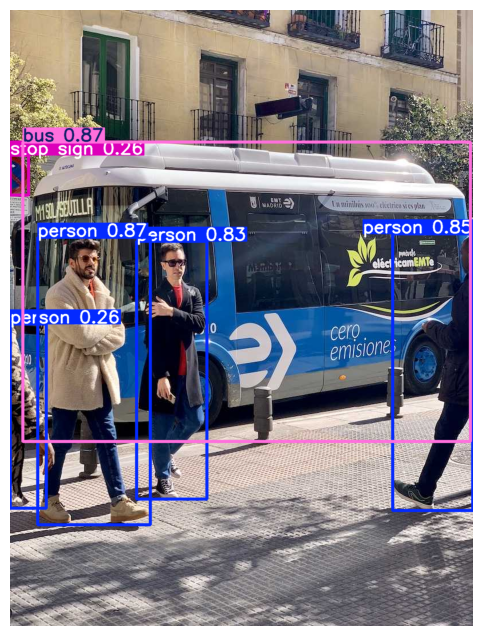

In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

#加载模型
model = YOLO("yolov8n.pt")  
#打开图片
img_path = "../data/bus.jpg"
img = Image.open(img_path)

#执行预测
results = model(img)

#显示结果
res_plotted = results[0].plot()
plt.figure(figsize=(12, 8))
plt.imshow(res_plotted[:, :, ::-1])
plt.axis('off')
plt.show()

# UNet分割COCO128-Seg

Using device: cpu
数据集已存在，直接使用。
图像路径: D:/data\coco128-seg\images/train2017
标注路径: D:/data\coco128-seg\labels/train2017
训练集样本数: 102, 验证集样本数: 26


训练中: 100%|██████████████████████████████████████████████████████████████████████████| 26/26 [02:30<00:00,  5.81s/it]


Epoch 1: Train Loss = 0.6633, Val Loss = 0.5055


训练中: 100%|██████████████████████████████████████████████████████████████████████████| 26/26 [02:30<00:00,  5.78s/it]


Epoch 2: Train Loss = 0.3883, Val Loss = 0.3449


...

Epoch 8: Train Loss = 0.2729, Val Loss = 0.3534


训练中: 100%|██████████████████████████████████████████████████████████████████████████| 26/26 [02:23<00:00,  5.50s/it]


Epoch 9: Train Loss = 0.2713, Val Loss = 0.3353


训练中: 100%|██████████████████████████████████████████████████████████████████████████| 26/26 [02:21<00:00,  5.46s/it]


Epoch 10: Train Loss = 0.2733, Val Loss = 0.3363


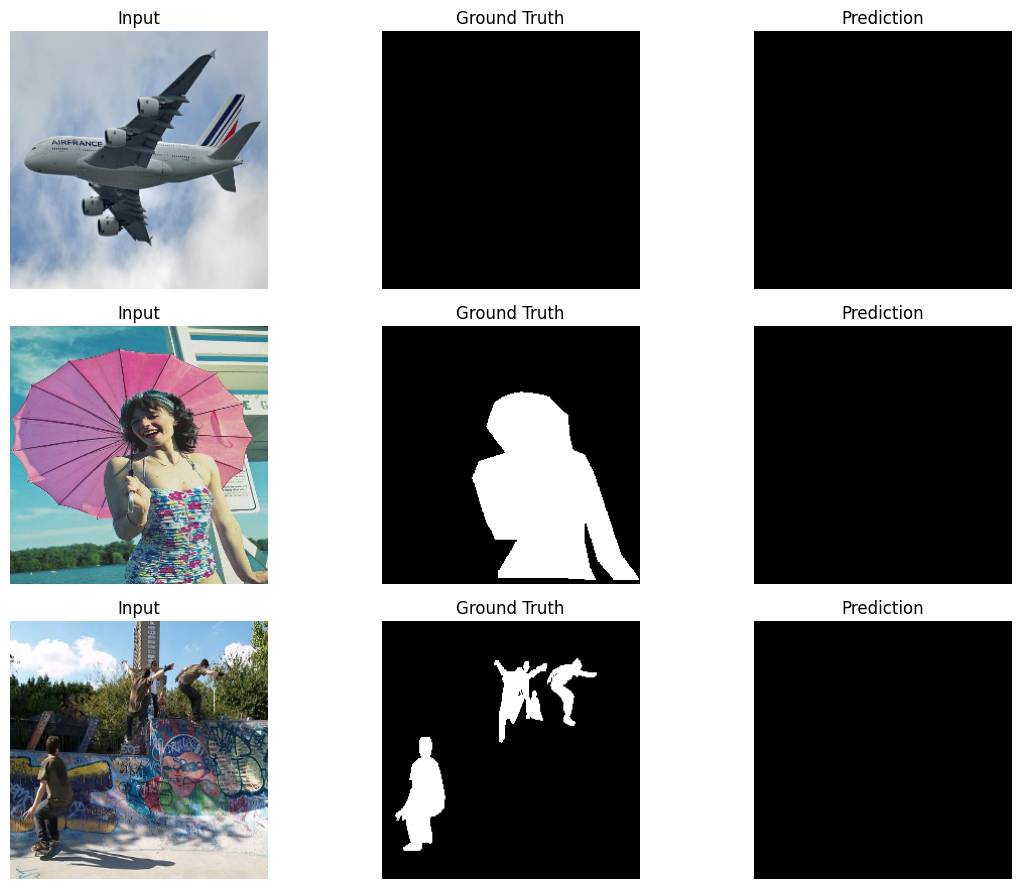

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import os
import zipfile
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#定义数据根目录
data_root = "D:/data"  # 可根据需要修改，确保D盘存在且有写入权限
os.makedirs(data_root, exist_ok=True)  # 如果文件夹不存在则创建

zip_path = os.path.join(data_root, "coco128-seg.zip")
extract_path = os.path.join(data_root, "coco128-seg")

# 检查数据集是否存在
if not os.path.exists(extract_path):
    if os.path.exists(zip_path):
        print("找到压缩包，正在解压...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("解压完成！")
    else:
        error_msg = f"""
        ************************************************************
        未找到数据集！请手动下载并放置到指定位置：
        1. 下载数据集（二选一）：
           - GitHub: https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip
           - 代理镜像: https://ghproxy.com/https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip
        2. 将下载的 coco128-seg.zip 文件放到目录： {data_root}
        3. 重新运行本单元格。
        ************************************************************
        """
        print(error_msg)
        raise FileNotFoundError("数据集未找到，请按上述指引手动下载。")
else:
    print("数据集已存在，直接使用。")

# 确定图像和标注路径
img_dir = os.path.join(extract_path, "images/train2017")
label_dir = os.path.join(extract_path, "labels/train2017")

# 如果路径不存在，尝试其他可能的解压结构
if not os.path.exists(img_dir):
    img_dir = os.path.join(extract_path, "images")
    label_dir = os.path.join(extract_path, "labels")

print(f"图像路径: {img_dir}")
print(f"标注路径: {label_dir}")

assert os.path.exists(img_dir), f"图像目录不存在: {img_dir}"
assert os.path.exists(label_dir), f"标注目录不存在: {label_dir}"
#自定义 Dataset 类 (将 YOLO 多边形标注转换为掩膜)
class COCO128SegDataset(Dataset):
    def __init__(self, img_dir, label_dir, target_class_id=0, img_size=256):
        """
        target_class_id: 要分割的类别ID，COCO中0是person
        """
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.target_class_id = target_class_id
        self.img_size = img_size
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.txt'))
        
        # 读取图像
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]
        
        # 创建空白掩膜 (背景=0, 目标=1)
        mask = np.zeros((h, w), dtype=np.uint8)
        
        # 读取YOLO格式标注（每一行：class_id x1 y1 x2 y2 ... 多边形点）
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    class_id = int(parts[0])
                    if class_id == self.target_class_id:  # 只保留目标类
                        # 解析多边形点 (YOLO格式是归一化的)
                        poly = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
                        # 反归一化到图像尺寸
                        poly[:, 0] *= w
                        poly[:, 1] *= h
                        poly = poly.astype(np.int32)
                        # 在掩膜上绘制多边形 (填充为1)
                        cv2.fillPoly(mask, [poly], 1)
        
        # 调整图像和掩膜大小
        image = cv2.resize(image, (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        
        # 转换为张量
        image = torch.from_numpy(image).permute(2,0,1).float() / 255.0  # (C, H, W)
        mask = torch.from_numpy(mask).long()  # (H, W)
        
        return image, mask

# 创建数据集和数据加载器
dataset = COCO128SegDataset(img_dir, label_dir, target_class_id=0)  # 分割人物

# 划分训练集和验证集
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"训练集样本数: {len(train_dataset)}, 验证集样本数: {len(val_dataset)}")

#定义 UNet 模型 (输出通道为2: 背景+前景)
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=2):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )
        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)
        self.bottleneck = conv_block(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = conv_block(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)
        self.out = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(nn.MaxPool2d(2)(e1))
        e3 = self.enc3(nn.MaxPool2d(2)(e2))
        e4 = self.enc4(nn.MaxPool2d(2)(e3))
        b = self.bottleneck(nn.MaxPool2d(2)(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.out(d1)

model = UNet().to(device)

#定义损失函数和优化器
criterion = nn.CrossEntropyLoss()  # 适合多类分割
optimizer = optim.Adam(model.parameters(), lr=1e-4)

#训练函数
def train_epoch(loader):
    model.train()
    total_loss = 0
    for images, masks in tqdm(loader, desc="训练中"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)  # (B, 2, H, W)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

#验证函数
def validate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item()
    return total_loss / len(loader)

#训练循环
epochs = 10
for epoch in range(1, epochs+1):
    train_loss = train_epoch(train_loader)
    val_loss = validate(val_loader)
    print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

#可视化预测结果
def visualize_predictions(loader, num=3):
    model.eval()
    fig, axes = plt.subplots(num, 3, figsize=(12, num*3))
    for i, (images, masks) in enumerate(loader):
        if i >= num: break
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)  # (B, H, W)
        
        # 取 batch 中第一张图显示
        img = images[0].cpu().numpy().transpose(1,2,0)
        mask = masks[0].cpu().numpy()
        pred = preds[0].cpu().numpy()
        
        axes[i,0].imshow(img)
        axes[i,0].set_title("Input")
        axes[i,0].axis('off')
        axes[i,1].imshow(mask, cmap="gray")
        axes[i,1].set_title("Ground Truth")
        axes[i,1].axis('off')
        axes[i,2].imshow(pred, cmap="gray")
        axes[i,2].set_title("Prediction")
        axes[i,2].axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(val_loader)

# VGG实现风格迁移

Using device: cpu
已将风格图尺寸调整为 128x80


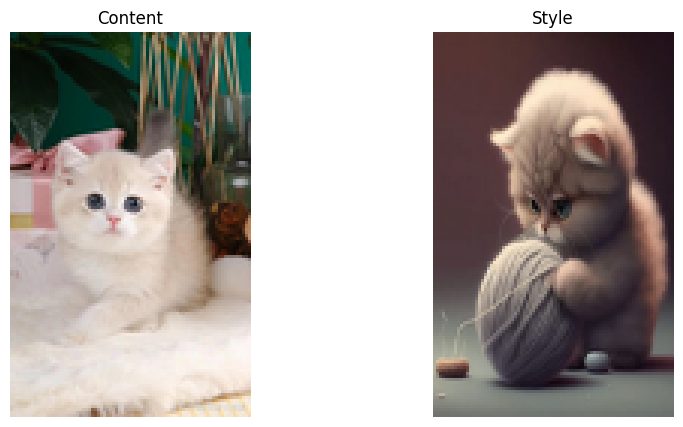

D:\anaconda\envs\py3.8\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\anaconda\envs\py3.8\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


开始风格迁移...
Iteration 0: loss = 74851336192.0000
Iteration 10: loss = 3312768000.0000
Iteration 20: loss = 2490208768.0000
Iteration 30: loss = 2186752512.0000
Iteration 40: loss = 2019477888.0000
Iteration 50: loss = 1938890368.0000
Iteration 60: loss = 1881022336.0000
Iteration 70: loss = 1837533824.0000
Iteration 80: loss = 1809345152.0000
Iteration 90: loss = 1786444288.0000


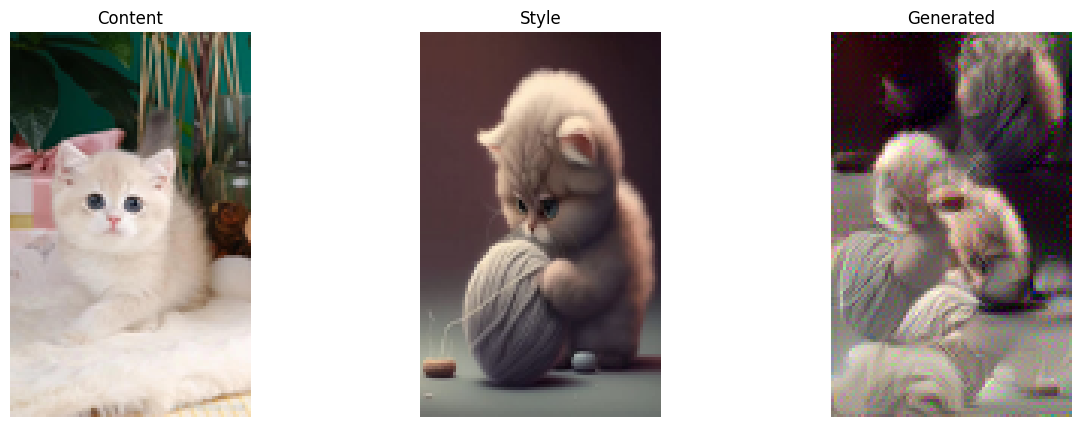

结果已保存到D:\data\VGGTF\stylized_output.jpg


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy
import torch.nn.functional as F

#设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#加载图像（保持原有逻辑）
def load_image(img_path, max_size=400):
    image = Image.open(img_path).convert('RGB')
    if max(image.size) > max_size:
        size = max_size
        ratio = float(size) / max(image.size)
        new_size = tuple([int(x*ratio) for x in image.size])
        image = image.resize(new_size, Image.Resampling.LANCZOS)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0)
    return image.to(device)

content_path = r"D:\data\VGGTF\rlcat.jpg"   #路径前加 r 防止转义
style_path   = r"D:\data\VGGTF\ctcat.jpg"       

content = load_image(content_path, max_size=128)
style   = load_image(style_path, max_size=128)

def make_same_size(content_tensor, style_tensor):
    if content_tensor.shape[2:] != style_tensor.shape[2:]:
        _, _, H, W = content_tensor.shape
        style_tensor = F.interpolate(style_tensor, size=(H, W), mode='bilinear', align_corners=False)
        print(f"已将风格图尺寸调整为 {H}x{W}")
    return content_tensor, style_tensor

content, style = make_same_size(content, style)

assert content.shape == style.shape, "内容图片和风格图片大小应一致"

#显示原始图片
def imshow(tensor, title=None):
    image = tensor.detach().cpu().clone().squeeze(0)   # 加上 .detach()
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    image = image.clip(0,1)
    plt.imshow(image.permute(1,2,0))
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); imshow(content, "Content")
plt.subplot(1,2,2); imshow(style, "Style")
plt.show()

#加载预训练VGG19
vgg = models.vgg19(pretrained=True).features.to(device).eval()

#需要提取特征的层
content_layers = ['conv_4_2']  # 内容损失使用的层
style_layers = ['conv_1_1', 'conv_2_1', 'conv_3_1', 'conv_4_1', 'conv_5_1']  # 风格损失使用的层

#归一化层（VGG预处理）
normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.view(-1,1,1)
        self.std = std.view(-1,1,1)
    def forward(self, img):
        return (img - self.mean) / self.std

#构建模型，使得前向传播能返回指定层的输出
class StyleContentModel(nn.Module):
    def __init__(self, vgg):
        super().__init__()
        self.vgg = vgg
        self.normalization = Normalization(normalization_mean, normalization_std)
        self.content_layers = content_layers
        self.style_layers = style_layers
        self._layers = {
            '0': 'conv_1_1',
            '2': 'conv_1_2',
            '5': 'conv_2_1',
            '7': 'conv_2_2',
            '10': 'conv_3_1',
            '12': 'conv_3_2',
            '14': 'conv_3_3',
            '17': 'conv_4_1',
            '19': 'conv_4_2',
            '21': 'conv_4_3',
            '24': 'conv_5_1',
            '26': 'conv_5_2',
            '28': 'conv_5_3',
        }
        self._reverse_layers = {v:k for k,v in self._layers.items()}

    def forward(self, x):
        outputs = {}
        x = self.normalization(x)
        for name, layer in self.vgg._modules.items():
            x = layer(x)
            if name in self._layers:
                layer_name = self._layers[name]
                if layer_name in self.style_layers or layer_name in self.content_layers:
                    outputs[layer_name] = x
        return outputs

extractor = StyleContentModel(vgg)

# 计算风格图片的特征和Gram矩阵，同时保存内容图片的特征
with torch.no_grad():
    style_features = extractor(style)
    style_grams = {}
    for layer in style_layers:
        f = style_features[layer]
        b, c, h, w = f.size()
        f = f.view(c, h * w)
        gram = torch.mm(f, f.t()) / (c * h * w)
        style_grams[layer] = gram

    # 新增：提取内容图片在 conv_4_2 层的特征，用于内容损失
    content_features = extractor(content)
    content_feat = content_features['conv_4_2']  # 与 content_layers 保持一致

# 准备要优化的图片（初始化为内容图片的副本）
target = content.clone().requires_grad_(True)

# 权重设置（可根据效果调整）
style_weights = {layer: 1e6 for layer in style_layers}
content_weight = 1
style_weight = 1e6   # 整体风格权重

optimizer = optim.LBFGS([target])

# 训练循环
print("开始风格迁移...")
for i in range(100):
    def closure():
        optimizer.zero_grad()
        target_features = extractor(target)

        # 内容损失（使用内容图的特征 content_feat）
        content_loss = torch.mean((target_features['conv_4_2'] - content_feat) ** 2)

        # 风格损失
        style_loss = 0
        for layer in style_layers:
            f = target_features[layer]
            b, c, h, w = f.size()
            f = f.view(c, h * w)
            gram = torch.mm(f, f.t()) / (c * h * w)
            style_loss += style_weights[layer] * torch.mean((gram - style_grams[layer]) ** 2)

        total_loss = content_weight * content_loss + style_weight * style_loss
        total_loss.backward()
        return total_loss

    # optimizer.step 会返回 closure 的返回值，即 total_loss
    loss = optimizer.step(closure)

    if i % 10 == 0:
        print(f"Iteration {i}: loss = {loss.item():.4f}")

#显示结果
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); imshow(content, "Content")
plt.subplot(1,3,2); imshow(style, "Style")
plt.subplot(1,3,3); imshow(target, "Generated")
plt.show()

#保存结果
im = target.detach().cpu().clone().squeeze(0)   # 加上 .detach()
im = im * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
im = im.clip(0,1)
to_pil = transforms.ToPILImage()(im)
to_pil.save(r"D:\data\VGGTF\stylized_output.jpg")
print("结果已保存到D:\data\VGGTF\stylized_output.jpg")

Using device: cpu
已将风格图尺寸调整为 256x160


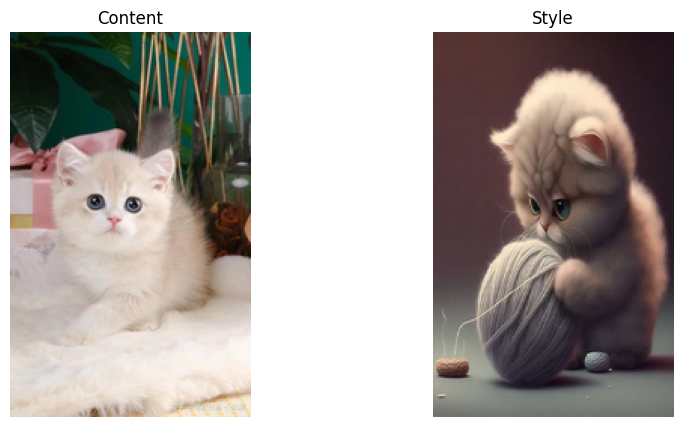

开始风格迁移...
Iteration 0: loss = 42257666048.0000
Iteration 10: loss = 507208096.0000
Iteration 20: loss = 291040192.0000
Iteration 30: loss = 234960656.0000
Iteration 40: loss = 206526272.0000
Iteration 50: loss = 188157264.0000
Iteration 60: loss = 174498544.0000
Iteration 70: loss = 165251776.0000
Iteration 80: loss = 159369808.0000
Iteration 90: loss = 155188608.0000
Iteration 100: loss = 151931072.0000
Iteration 110: loss = 149423184.0000
Iteration 120: loss = 147293408.0000
Iteration 130: loss = 145545056.0000
Iteration 140: loss = 143971648.0000
Iteration 150: loss = 142665664.0000
Iteration 160: loss = 141523088.0000
Iteration 170: loss = 140495536.0000
Iteration 180: loss = 139574768.0000
Iteration 190: loss = 138803568.0000
Iteration 200: loss = 138111408.0000
Iteration 210: loss = 137517584.0000
Iteration 220: loss = 136962080.0000
Iteration 230: loss = 136437632.0000
Iteration 240: loss = 135954480.0000
Iteration 250: loss = 135522320.0000
Iteration 260: loss = 135124480.0000


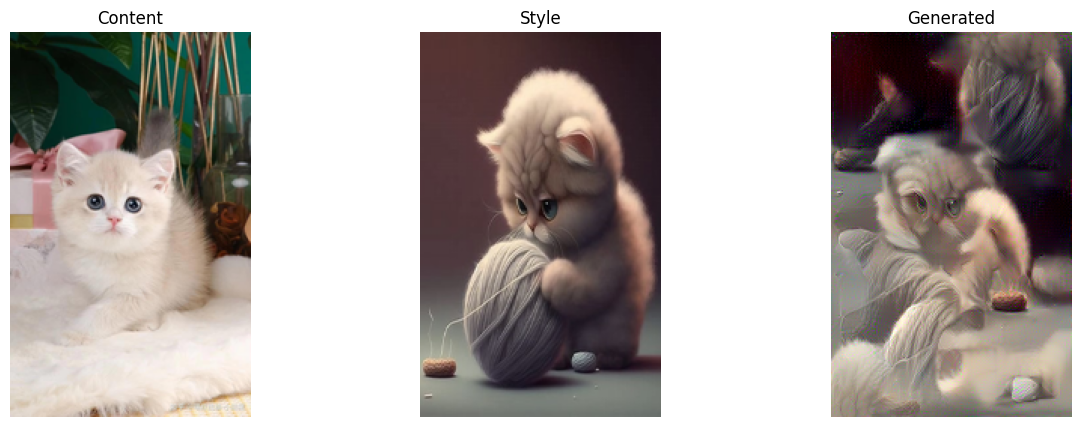

结果已保存到D:\data\VGGTF\stylized_output.jpg


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import copy
import torch.nn.functional as F

#设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#加载图像（保持原有逻辑）
def load_image(img_path, max_size=400):
    image = Image.open(img_path).convert('RGB')
    if max(image.size) > max_size:
        size = max_size
        ratio = float(size) / max(image.size)
        new_size = tuple([int(x*ratio) for x in image.size])
        image = image.resize(new_size, Image.Resampling.LANCZOS)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0)
    return image.to(device)

content_path = r"D:\data\VGGTF\rlcat.jpg"   #路径前加 r 防止转义
style_path   = r"D:\data\VGGTF\ctcat.jpg"       

content = load_image(content_path, max_size=256)
style   = load_image(style_path, max_size=256)

def make_same_size(content_tensor, style_tensor):
    if content_tensor.shape[2:] != style_tensor.shape[2:]:
        _, _, H, W = content_tensor.shape
        style_tensor = F.interpolate(style_tensor, size=(H, W), mode='bilinear', align_corners=False)
        print(f"已将风格图尺寸调整为 {H}x{W}")
    return content_tensor, style_tensor

content, style = make_same_size(content, style)

assert content.shape == style.shape, "内容图片和风格图片大小应一致"

#显示原始图片
def imshow(tensor, title=None):
    image = tensor.detach().cpu().clone().squeeze(0)   # 加上 .detach()
    image = image * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    image = image.clip(0,1)
    plt.imshow(image.permute(1,2,0))
    if title:
        plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); imshow(content, "Content")
plt.subplot(1,2,2); imshow(style, "Style")
plt.show()

#加载预训练VGG19
vgg = models.vgg19(pretrained=True).features.to(device).eval()

#需要提取特征的层
content_layers = ['conv_4_2']  # 内容损失使用的层
style_layers = ['conv_1_1', 'conv_2_1', 'conv_3_1', 'conv_4_1', 'conv_5_1']  # 风格损失使用的层

#归一化层（VGG预处理）
normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

class Normalization(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.mean = mean.view(-1,1,1)
        self.std = std.view(-1,1,1)
    def forward(self, img):
        return (img - self.mean) / self.std

#构建模型，使得前向传播能返回指定层的输出
class StyleContentModel(nn.Module):
    def __init__(self, vgg):
        super().__init__()
        self.vgg = vgg
        self.normalization = Normalization(normalization_mean, normalization_std)
        self.content_layers = content_layers
        self.style_layers = style_layers
        self._layers = {
            '0': 'conv_1_1',
            '2': 'conv_1_2',
            '5': 'conv_2_1',
            '7': 'conv_2_2',
            '10': 'conv_3_1',
            '12': 'conv_3_2',
            '14': 'conv_3_3',
            '17': 'conv_4_1',
            '19': 'conv_4_2',
            '21': 'conv_4_3',
            '24': 'conv_5_1',
            '26': 'conv_5_2',
            '28': 'conv_5_3',
        }
        self._reverse_layers = {v:k for k,v in self._layers.items()}

    def forward(self, x):
        outputs = {}
        x = self.normalization(x)
        for name, layer in self.vgg._modules.items():
            x = layer(x)
            if name in self._layers:
                layer_name = self._layers[name]
                if layer_name in self.style_layers or layer_name in self.content_layers:
                    outputs[layer_name] = x
        return outputs

extractor = StyleContentModel(vgg)

# 计算风格图片的特征和Gram矩阵，同时保存内容图片的特征
with torch.no_grad():
    style_features = extractor(style)
    style_grams = {}
    for layer in style_layers:
        f = style_features[layer]
        b, c, h, w = f.size()
        f = f.view(c, h * w)
        gram = torch.mm(f, f.t()) / (c * h * w)
        style_grams[layer] = gram

    # 新增：提取内容图片在 conv_4_2 层的特征，用于内容损失
    content_features = extractor(content)
    content_feat = content_features['conv_4_2']  # 与 content_layers 保持一致

# 准备要优化的图片（初始化为内容图片的副本）
target = content.clone().requires_grad_(True)

# 权重设置（可根据效果调整）
style_weights = {layer: 1e6 for layer in style_layers}
content_weight = 1
style_weight = 1e6   # 整体风格权重

optimizer = optim.LBFGS([target])

# 训练循环
print("开始风格迁移...")
for i in range(300):
    def closure():
        optimizer.zero_grad()
        target_features = extractor(target)

        # 内容损失（使用内容图的特征 content_feat）
        content_loss = torch.mean((target_features['conv_4_2'] - content_feat) ** 2)

        # 风格损失
        style_loss = 0
        for layer in style_layers:
            f = target_features[layer]
            b, c, h, w = f.size()
            f = f.view(c, h * w)
            gram = torch.mm(f, f.t()) / (c * h * w)
            style_loss += style_weights[layer] * torch.mean((gram - style_grams[layer]) ** 2)

        total_loss = content_weight * content_loss + style_weight * style_loss
        total_loss.backward()
        return total_loss

    # optimizer.step 会返回 closure 的返回值，即 total_loss
    loss = optimizer.step(closure)

    if i % 10 == 0:
        print(f"Iteration {i}: loss = {loss.item():.4f}")

#显示结果
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); imshow(content, "Content")
plt.subplot(1,3,2); imshow(style, "Style")
plt.subplot(1,3,3); imshow(target, "Generated")
plt.show()

#保存结果
im = target.detach().cpu().clone().squeeze(0)   # 加上 .detach()
im = im * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
im = im.clip(0,1)
to_pil = transforms.ToPILImage()(im)
to_pil.save(r"D:\data\VGGTF\stylized_output.jpg")
print("结果已保存到D:\data\VGGTF\stylized_output.jpg")

# DCGAN 生成手写数字